<a href="https://colab.research.google.com/github/pyaramsravanthi/AI-Assisted-Threat-Detection-Dashboard/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Assisted Threat Detection Dashboard

## Prompt 1: Generate Synthetic Threat Data

**Task:** Generate a synthetic dataset representing network traffic or system logs, including both normal activity and a small percentage of anomalous (threat) activities. The dataset should contain features relevant for threat detection, such as 'timestamp', 'source_ip', 'destination_ip', 'port', 'protocol', 'packet_size', 'connection_duration', and a 'threat' label.

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

def generate_synthetic_data(num_samples=1000, num_threats=20):
    data = {
        'timestamp': [datetime.now() - timedelta(minutes=i) for i in range(num_samples)],
        'source_ip': [f'192.168.1.{np.random.randint(1, 255)}' for _ in range(num_samples)],
        'destination_ip': [f'10.0.0.{np.random.randint(1, 255)}' for _ in range(num_samples)],
        'port': np.random.randint(1, 65535, num_samples),
        'protocol': np.random.choice(['TCP', 'UDP', 'ICMP'], num_samples, p=[0.7, 0.25, 0.05]),
        'packet_size': np.random.normal(500, 150, num_samples).astype(int),
        'connection_duration': np.random.exponential(5, num_samples).astype(int),
        'bytes_transferred': np.random.normal(1000, 300, num_samples).astype(int),
        'threat': 0
    }
    df = pd.DataFrame(data)


    threat_indices = np.random.choice(num_samples, num_threats, replace=False)
    df.loc[threat_indices, 'threat'] = 1
    df.loc[threat_indices, 'packet_size'] = np.random.normal(2000, 500, num_threats).astype(int) # Larger packets
    df.loc[threat_indices, 'connection_duration'] = np.random.exponential(30, num_threats).astype(int) # Longer durations
    df.loc[threat_indices, 'bytes_transferred'] = np.random.normal(5000, 1000, num_threats).astype(int)
    df.loc[threat_indices, 'port'] = np.random.choice([20, 21, 22, 23, 80, 443, 3389], num_threats)
    df.loc[threat_indices, 'protocol'] = 'TCP'

    return df.sort_values('timestamp', ascending=True).reset_index(drop=True)

df = generate_synthetic_data(num_samples=2000, num_threats=40)
display(df.head())
display(df['threat'].value_counts())

,timestamp,source_ip,destination_ip,port,protocol,packet_size,connection_duration,bytes_transferred,threat
0,2026-07-01 03:43:23.326370,192.168.1.210,10.0.0.196,1425,TCP,537,3,788,0
1,2026-07-01 03:44:23.326369,192.168.1.25,10.0.0.21,16524,TCP,267,1,959,0
2,2026-07-01 03:45:23.326368,192.168.1.200,10.0.0.185,32027,UDP,326,5,1021,0
3,2026-07-01 03:46:23.326367,192.168.1.198,10.0.0.107,26501,UDP,624,1,1073,0
4,2026-07-01 03:47:23.326367,192.168.1.208,10.0.0.250,59723,UDP,673,13,385,0


,count
threat,
0,1960
1,40


## Prompt 2: Data Preprocessing and Feature Engineering

**Task:** Preprocess the synthetic dataset. This involves converting 'timestamp' to datetime objects, extracting time-based features (e.g., hour, day of week), encoding categorical features (e.g., 'protocol'), and scaling numerical features. Handle any potential missing values if the dataset were real.

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_of_month'] = df['timestamp'].dt.day


le_protocol = LabelEncoder()
df['protocol_encoded'] = le_protocol.fit_transform(df['protocol'])

features = ['hour', 'day_of_week', 'day_of_month', 'port', 'packet_size', 'connection_duration', 'bytes_transferred', 'protocol_encoded']
X = df[features]
y = df['threat']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_processed = pd.DataFrame(X_scaled, columns=features)

display(X_processed.head())
display(y.head())

,hour,day_of_week,day_of_month,port,packet_size,connection_duration,bytes_transferred,protocol_encoded
0,-1.195577,-0.802113,-0.802113,-1.547454,0.026049,-0.235637,-0.430353,-0.438486
1,-1.195577,-0.802113,-0.802113,-0.763333,-1.015974,-0.440272,-0.178412,-0.438486
2,-1.195577,-0.802113,-0.802113,0.041769,-0.788273,-0.031002,-0.087065,1.582186
3,-1.195577,-0.802113,-0.802113,-0.245207,0.361811,-0.440272,-0.010452,1.582186
4,-1.195577,-0.802113,-0.802113,1.480078,0.550919,0.787538,-1.024108,1.582186


,threat
0,0
1,0
2,0
3,0
4,0


## Prompt 3: Train an Anomaly Detection Model

**Task:** Train an anomaly detection model on the processed data. Since threat detection is often about identifying rare events, unsupervised anomaly detection algorithms like Isolation Forest or One-Class SVM are suitable. Use Isolation Forest to train a model to identify anomalies, assuming that 'threat' label is only used for evaluation, and the training data is mostly 'normal'.

In [8]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(random_state=42, contamination=0.02)
model.fit(X_processed)

df['anomaly_prediction'] = model.predict(X_processed)

df['anomaly_prediction'] = df['anomaly_prediction'].apply(lambda x: 1 if x == -1 else 0)

display(df[['threat', 'anomaly_prediction']].head())
display(df['anomaly_prediction'].value_counts())

,threat,anomaly_prediction
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


,count
anomaly_prediction,
0,1960
1,40


## Prompt 4: Evaluate Model Performance

**Task:** Evaluate the performance of the trained anomaly detection model using appropriate metrics for imbalanced datasets. Calculate precision, recall, F1-score, and the confusion matrix, comparing the model's 'anomaly_prediction' with the true 'threat' labels.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1960
           1       0.88      0.88      0.88        40

    accuracy                           0.99      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.99      0.99      0.99      2000



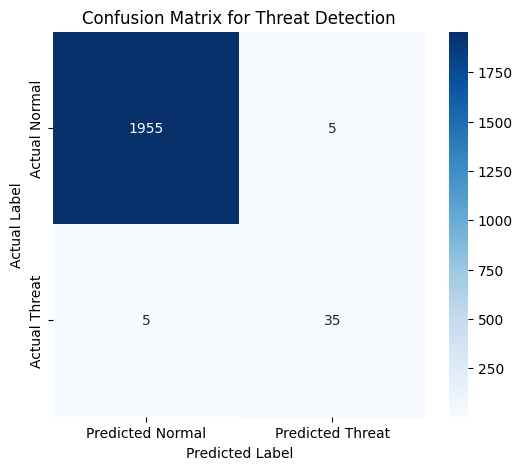

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = df['threat']
y_pred = df['anomaly_prediction']

print("Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Threat'],
            yticklabels=['Actual Normal', 'Actual Threat'])
plt.title('Confusion Matrix for Threat Detection')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Prompt 5: Implement Real-time Threat Scoring (Simulation)

**Task:** Simulate real-time threat scoring. Generate a few new data points and use the trained Isolation Forest model to predict if they are anomalous. Display the new data points along with their anomaly scores and predictions.

In [10]:
def generate_new_data_point(is_threat=False):
    new_data = {
        'timestamp': datetime.now(),
        'source_ip': f'192.168.1.{np.random.randint(1, 255)}',
        'destination_ip': f'10.0.0.{np.random.randint(1, 255)}',
        'port': np.random.randint(1, 65535),
        'protocol': np.random.choice(['TCP', 'UDP', 'ICMP'], p=[0.7, 0.25, 0.05]),
        'packet_size': int(np.random.normal(500, 150)),
        'connection_duration': int(np.random.exponential(5)),
        'bytes_transferred': int(np.random.normal(1000, 300)),
    }
    if is_threat:
        new_data['packet_size'] = int(np.random.normal(2500, 500))
        new_data['connection_duration'] = int(np.random.exponential(40))
        new_data['bytes_transferred'] = int(np.random.normal(6000, 1500))
        new_data['port'] = np.random.choice([20, 21, 22, 23, 3389]) # Common threat ports
        new_data['protocol'] = 'TCP'
    return pd.DataFrame([new_data])

new_normal_data = generate_new_data_point(is_threat=False)
new_threat_data = generate_new_data_point(is_threat=True)


new_df = pd.concat([new_normal_data, new_threat_data], ignore_index=True)
new_df['hour'] = new_df['timestamp'].dt.hour
new_df['day_of_week'] = new_df['timestamp'].dt.dayofweek
new_df['day_of_month'] = new_df['timestamp'].dt.day
new_df['protocol_encoded'] = le_protocol.transform(new_df['protocol'])

X_new = new_df[features]
X_new_scaled = scaler.transform(X_new)

anomaly_scores = model.decision_function(X_new_scaled)
anomaly_predictions = model.predict(X_new_scaled)
anomaly_predictions = [1 if x == -1 else 0 for x in anomaly_predictions]

new_df['anomaly_score'] = anomaly_scores
new_df['anomaly_prediction'] = anomaly_predictions

print("Simulated Real-time Threat Scoring:")
display(new_df[['timestamp', 'source_ip', 'destination_ip', 'port', 'packet_size', 'connection_duration', 'anomaly_score', 'anomaly_prediction']])

Simulated Real-time Threat Scoring:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


,timestamp,source_ip,destination_ip,port,packet_size,connection_duration,anomaly_score,anomaly_prediction
0,2026-07-02 13:02:25.434410,192.168.1.9,10.0.0.3,48822,688,9,0.112633,0
1,2026-07-02 13:02:25.436321,192.168.1.191,10.0.0.16,23,2260,19,-0.017206,1


## Prompt 6: Visualize Threat Detections Over Time

**Task:** Create a time-series plot showing the number of detected threats over time. This helps in understanding threat trends and identifying periods of high activity, which is crucial for a dashboard. Use the 'anomaly_prediction' from the full dataset.

/tmp/ipykernel_3341/1084628757.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  threat_over_time = df.set_index('timestamp').resample('H')['anomaly_prediction'].sum().reset_index()


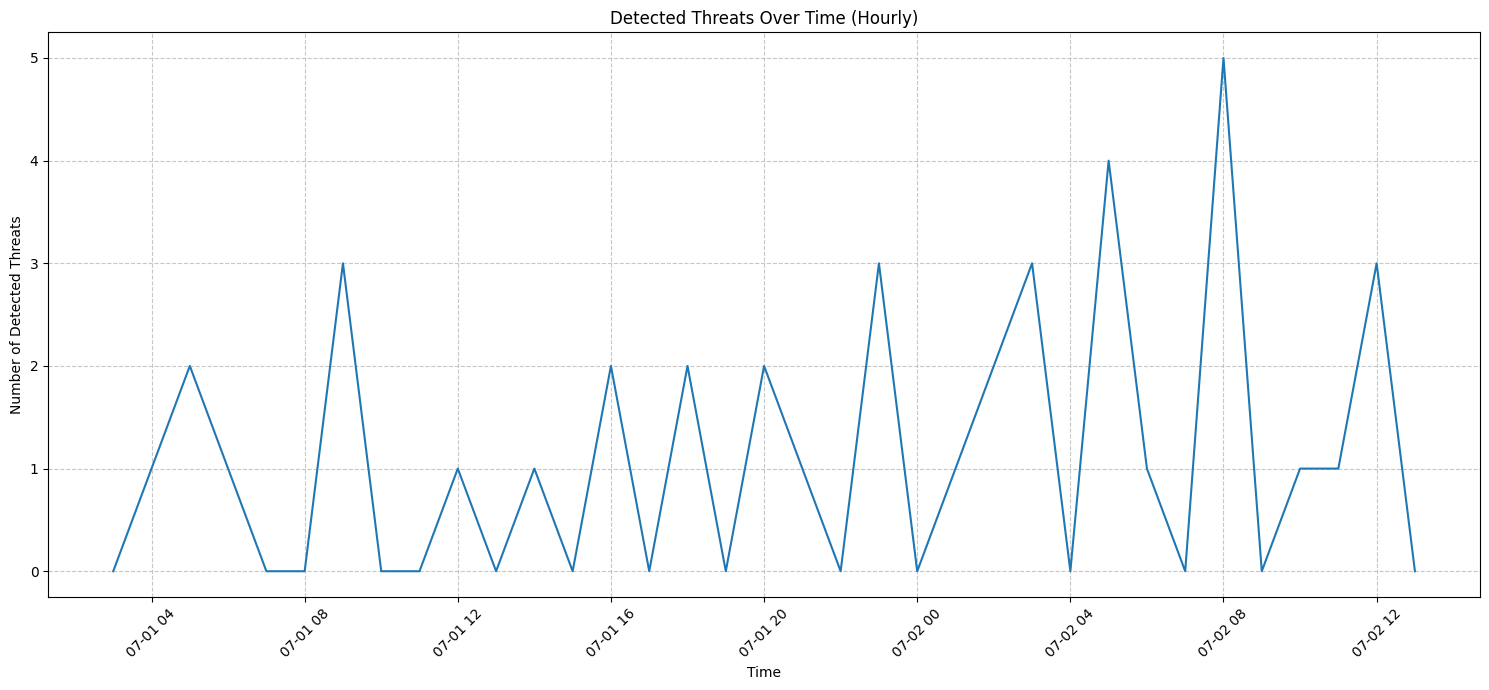

In [11]:
threat_over_time = df.set_index('timestamp').resample('H')['anomaly_prediction'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='anomaly_prediction', data=threat_over_time)
plt.title('Detected Threats Over Time (Hourly)')
plt.xlabel('Time')
plt.ylabel('Number of Detected Threats')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Prompt 7: Identify Top Threat Indicators

**Task:** Analyze the features of the detected anomalies to identify common characteristics or 'indicators' of threat. For example, which ports, protocols, or IP addresses are most frequently associated with detected threats?

In [12]:
threat_indicators = df[df['anomaly_prediction'] == 1]

print("Top 5 Source IPs in Detected Threats:")
display(threat_indicators['source_ip'].value_counts().head())

print("Top 5 Destination IPs in Detected Threats:")
display(threat_indicators['destination_ip'].value_counts().head())

print("Top 5 Ports in Detected Threats:")
display(threat_indicators['port'].value_counts().head())

print("Protocols in Detected Threats:")
display(threat_indicators['protocol'].value_counts())

Top 5 Source IPs in Detected Threats:


,count
source_ip,
192.168.1.54,3
192.168.1.248,2
192.168.1.220,2
192.168.1.42,1
192.168.1.244,1


Top 5 Destination IPs in Detected Threats:


,count
destination_ip,
10.0.0.208,2
10.0.0.107,2
10.0.0.49,2
10.0.0.10,2
10.0.0.4,1


Top 5 Ports in Detected Threats:


,count
port,
23,7
80,5
443,5
21,5
3389,5


Protocols in Detected Threats:


,count
protocol,
TCP,35
ICMP,4
UDP,1


## Prompt 8: Create a Threat Severity Score (Simple)

**Task:** Develop a simple threat severity score based on the anomaly score. For instance, events with a very low anomaly score (highly anomalous) could be assigned a higher severity. Categorize threats into 'Low', 'Medium', 'High' severity.

In [13]:
df['anomaly_score'] = model.decision_function(X_processed)

def assign_severity(score):
    if score < model.offset_ - 0.1:
        return 'High'
    elif score < model.offset_:
        return 'Medium'
    else:
        return 'Low'

df['threat_severity'] = df['anomaly_score'].apply(assign_severity)

display(df[df['anomaly_prediction'] == 1][['timestamp', 'source_ip', 'destination_ip', 'anomaly_score', 'threat_severity']].sort_values('anomaly_score').head(10))

,timestamp,source_ip,destination_ip,anomaly_score,threat_severity
1570,2026-07-02 05:53:23.323025,192.168.1.248,10.0.0.208,-0.132374,Low
1284,2026-07-02 01:07:23.324685,192.168.1.161,10.0.0.222,-0.125012,Low
1531,2026-07-02 05:14:23.324280,192.168.1.35,10.0.0.50,-0.110138,Low
1095,2026-07-01 21:58:23.325236,192.168.1.220,10.0.0.220,-0.105476,Low
1957,2026-07-02 12:20:23.322675,192.168.1.220,10.0.0.17,-0.104278,Low
1716,2026-07-02 08:19:23.322902,192.168.1.113,10.0.0.107,-0.103412,Low
994,2026-07-01 20:17:23.325403,192.168.1.134,10.0.0.21,-0.099619,Low
1544,2026-07-02 05:27:23.323059,192.168.1.21,10.0.0.208,-0.099251,Low
182,2026-07-01 06:45:23.326184,192.168.1.244,10.0.0.4,-0.095281,Low
1960,2026-07-02 12:23:23.322672,192.168.1.219,10.0.0.187,-0.094501,Low


## Prompt 9: Generate a Summary Threat Report

**Task:** Generate a textual summary report of the detected threats, including the total number of threats, the distribution of threat severities, and a list of the most critical threats (e.g., top 5 high-severity threats).

In [14]:
total_threats = df['anomaly_prediction'].sum()
severity_counts = df[df['anomaly_prediction'] == 1]['threat_severity'].value_counts()
high_severity_threats = df[(df['anomaly_prediction'] == 1) & (df['threat_severity'] == 'High')].sort_values('anomaly_score').head(5)

print("--- AI-Assisted Threat Detection Summary Report ---")
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Detected Threats: {total_threats}")
print("\nThreat Severity Distribution:")
print(severity_counts.to_string())

print("\nTop 5 High Severity Threats:")
if not high_severity_threats.empty:
    for index, row in high_severity_threats.iterrows():
        print(f"  - Timestamp: {row['timestamp'].strftime('%Y-%m-%d %H:%M:%S')}, Source IP: {row['source_ip']}, Dest IP: {row['destination_ip']}, Port: {row['port']}, Score: {row['anomaly_score']:.2f}")
else:
    print("  No high severity threats detected.")
print("--------------------------------------------------")

--- AI-Assisted Threat Detection Summary Report ---
Date: 2026-07-02 13:02:27
Total Detected Threats: 40

Threat Severity Distribution:
threat_severity
Low    40

Top 5 High Severity Threats:
  No high severity threats detected.
--------------------------------------------------


## Prompt 10: Model Persistence (Save and Load)

**Task:** Demonstrate how to save the trained Isolation Forest model, as well as the scaler and label encoder, to disk. Then, load them back to ensure the model can be reused without retraining.

In [15]:
import joblib
import os

model_path = 'isolation_forest_model.joblib'
scaler_path = 'standard_scaler.joblib'
le_protocol_path = 'label_encoder_protocol.joblib'

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(le_protocol, le_protocol_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Label Encoder saved to: {le_protocol_path}"

loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_le_protocol = joblib.load(le_protocol_path)

print("\nModel, Scaler, and Label Encoder loaded successfully.")

test_data_point = generate_new_data_point(is_threat=True)
test_data_point['hour'] = test_data_point['timestamp'].dt.hour
test_data_point['day_of_week'] = test_data_point['timestamp'].dt.dayofweek
test_data_point['day_of_month'] = test_data_point['timestamp'].dt.day
test_data_point['protocol_encoded'] = loaded_le_protocol.transform(test_data_point['protocol'])

X_test = test_data_point[features]
X_test_scaled = loaded_scaler.transform(X_test)

loaded_prediction = loaded_model.predict(X_test_scaled)
loaded_score = loaded_model.decision_function(X_test_scaled)

print("\nPrediction with loaded model:")
print(f"Raw prediction: {loaded_prediction[0]} (1=inlier, -1=outlier)")
print(f"Anomaly score: {loaded_score[0]:.2f}")
print(f"Interpreted prediction: {'Threat Detected' if loaded_prediction[0] == -1 else 'Normal'}")


os.remove(model_path)
os.remove(scaler_path)
os.remove(le_protocol_path)
print("\nCleaned up saved files.")

Model saved to: isolation_forest_model.joblib
Scaler saved to: standard_scaler.joblib
Label Encoder saved to: label_encoder_protocol.joblib

Model, Scaler, and Label Encoder loaded successfully.

Prediction with loaded model:
Raw prediction: -1 (1=inlier, -1=outlier)
Anomaly score: -0.08
Interpreted prediction: Threat Detected

Cleaned up saved files.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
